In [27]:
pip --version

pip 20.2.4 from /usr/lib/python3.9/site-packages/pip (python 3.9)
Note: you may need to restart the kernel to use updated packages.


In [29]:
pip install statsmodels


Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 10.4 MB 1.8 MB/s eta 0:00:01
     |████████████████████████████████| 233 kB 94.3 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [32]:
import sys; print(sys.version)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

%matplotlib inline
df = pd.read_csv("week-5-country-life-satisfaction.csv", index_col=0)
df.head()

3.9.25 (main, Dec 19 2025, 15:38:47) 
[GCC 8.5.0 20210514 (Red Hat 8.5.0-28.0.1)]


,Name,LifeSat,CountryCode,Region,HDI,LE,EYS,MYS,GNI
1,Afghanistan,3.794,AFG,South Asia,0.495960,64.486,10.138920,3.930000,1745.665705
2,Albania,4.644,ALB,Europe & Central Asia,0.791406,78.458,15.230000,10.054618,12299.799340
3,Algeria,5.872,DZA,Middle East & North Africa,0.758978,76.693,14.719379,7.986548,13639.434910
4,Angola,3.795,AGO,Sub-Saharan Africa,0.574488,60.782,11.777202,5.125460,5554.697384
5,Argentina,6.599,ARG,Latin America & Caribbean,0.830096,76.520,17.638360,10.564965,17611.218130


In [33]:
#Q1a
df = pd.read_csv("week-5-country-life-satisfaction.csv")
df.head()
print(f"Shape of the dataframe : {df.shape}")
print()
print(df.dtypes)
print()
print(df.isnull().sum())

Shape of the dataframe : (134, 10)

Unnamed: 0       int64
Name            object
LifeSat        float64
CountryCode     object
Region          object
HDI            float64
LE             float64
EYS            float64
MYS            float64
GNI            float64
dtype: object

Unnamed: 0     0
Name           0
LifeSat        0
CountryCode    0
Region         0
HDI            0
LE             0
EYS            0
MYS            0
GNI            0
dtype: int64


In [37]:
#Q1b
df["logGNI"] = np.log(df["GNI"])
df.head()

,Unnamed: 0,Name,LifeSat,CountryCode,Region,HDI,LE,EYS,MYS,GNI,logGNI
0,1,Afghanistan,3.794,AFG,South Asia,0.495960,64.486,10.138920,3.930000,1745.665705,7.464891
1,2,Albania,4.644,ALB,Europe & Central Asia,0.791406,78.458,15.230000,10.054618,12299.799340,9.417338
2,3,Algeria,5.872,DZA,Middle East & North Africa,0.758978,76.693,14.719379,7.986548,13639.434910,9.520721
3,4,Angola,3.795,AGO,Sub-Saharan Africa,0.574488,60.782,11.777202,5.125460,5554.697384,8.622399
4,5,Argentina,6.599,ARG,Latin America & Caribbean,0.830096,76.520,17.638360,10.564965,17611.218130,9.776291


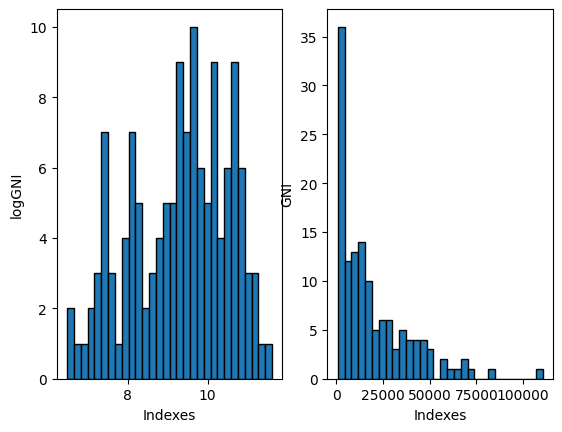

In [81]:
#Q1c
plt.subplot(1,2,1)
plt.hist(df["logGNI"],bins=30,edgecolor="black")
plt.xlabel("Indexes")
plt.ylabel("logGNI")

plt.subplot(1,2,2)
plt.hist(df["GNI"],bins=30,edgecolor="black")
plt.xlabel("Indexes")
plt.ylabel("GNI")

plt.show()

#As the values in the GNi are right skewed we need to convert them to log distribution to get a uniform distribution 

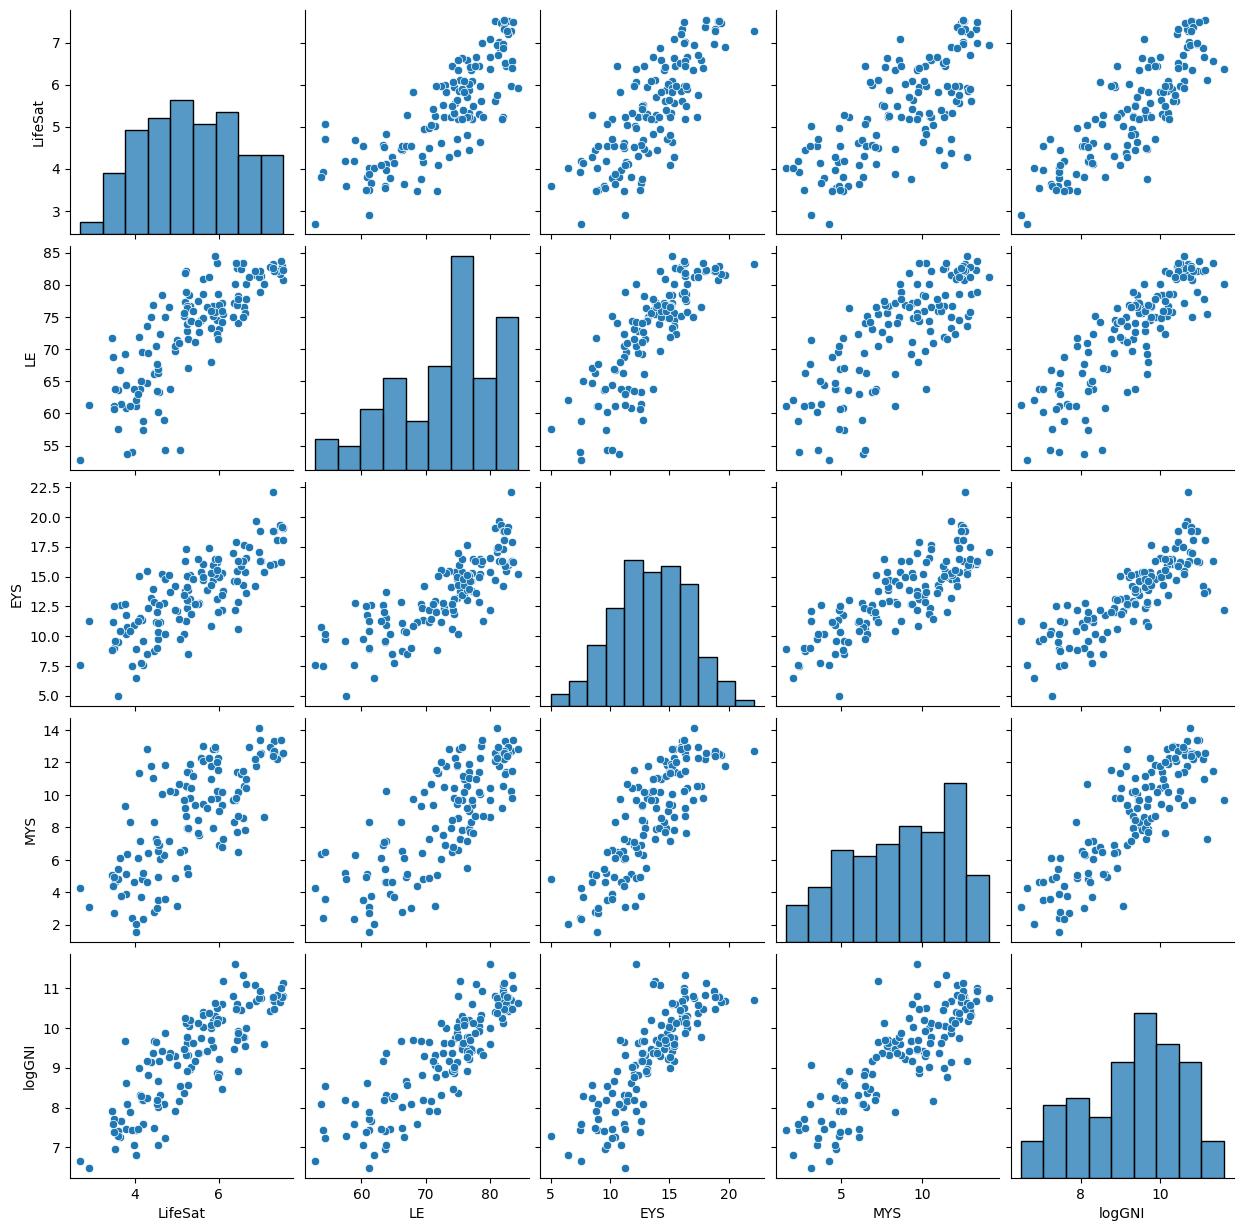

In [59]:
#Q1c
sns.pairplot(df[["LifeSat","LE","EYS","MYS","logGNI"]])

<Axes: >

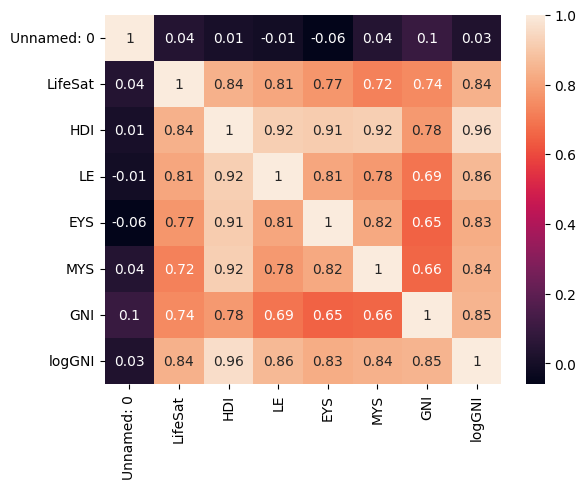

In [67]:
#Q1c
df_temp = df.drop(columns=["Name","CountryCode","Region"],axis=1)
sns.heatmap(round(df_temp.corr(),2),annot=True)

In [82]:
#Q1d
#The indicator that most strongly correlatred with LifeSat is GNI with 0.84 pearson correlation coef
#logGNI AND HDI are the most correlatred with 0.96 pearson correlation coef

In [315]:
#Q2a
m = smf.ols("LifeSat ~ LE + EYS + MYS + logGNI", data=df_new).fit()
print(m.summary())

print(m.rsquared)
print(m.rsquared_adj)

print()
print(m.pvalues)


                            OLS Regression Results                            
Dep. Variable:                LifeSat   R-squared:                       0.740
Model:                            OLS   Adj. R-squared:                  0.732
Method:                 Least Squares   F-statistic:                     91.77
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           9.07e-37
Time:                        16:54:01   Log-Likelihood:                -120.17
No. Observations:                 134   AIC:                             250.3
Df Residuals:                     129   BIC:                             264.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.9442      0.668     -4.405      0.0

In [177]:
#Q2b
eq = "-0.0415*LE + 0.0654*EYS -0.290*MYS + logGNI*0.5017 - 2.9442"
print(eq)

-0.0415*LE + 0.0654*EYS -0.290*MYS + logGNI*0.5017 - 2.9442


In [179]:
#Q2c
print(m.pvalues)
#EYS and MYS not strongly correlated 
#LE and logGNI is much siginifacnt


Intercept    0.000022
LE           0.003047
EYS          0.058890
MYS          0.382734
logGNI       0.000002
dtype: float64


In [ ]:
#Q2d
#


In [182]:
#Q3a
model2 = smf.ols("LifeSat ~ LE + EYS + logGNI", data=df_new).fit()
print(model2.summary())


                            OLS Regression Results                            
Dep. Variable:                LifeSat   R-squared:                       0.738
Model:                            OLS   Adj. R-squared:                  0.732
Method:                 Least Squares   F-statistic:                     122.3
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           1.10e-37
Time:                        15:56:53   Log-Likelihood:                -120.56
No. Observations:                 134   AIC:                             249.1
Df Residuals:                     130   BIC:                             260.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.6394      0.570     -4.630      0.0

In [227]:
#Q3b
df_old = pd.read_csv("week-5-country-life-satisfaction.csv")
df_old 
df_old["logGNI"] = np.log(df_old["GNI"])
df_old.drop(columns=["Unnamed: 0","Name","CountryCode","Region"],axis=1)

corr = model2.fittedvalues.corr(df_old["HDI"])
print(corr)


0.9890412322483967


In [274]:
#Q4a
df_old["Residual"] = model2.resid
df_old.drop("Unnamed: 0",axis=1)

print(df_old["Name"].loc[df_old["Residual"].idxmax()])
print(df_old["Name"].loc[df_old["Residual"].idxmin()])

Guatemala
Botswana


In [328]:
#Q4b
cols = ["LifeSat","HDI","LE","EYS","MYS","GNI"]
df_q4b = pd.read_csv("week-5-country-life-satisfaction.csv")
df_q4b["logGNI"] = np.log(df_old["GNI"])
df_q4b["Residual"] = pd.DataFrame(model2.resid)

df_q4b.drop(columns=["Unnamed: 0","Name","CountryCode","Region"],axis=1)

print(df_q4b.loc[[df_q4b["Residulal"].idxmax(),df_q4b["Residual"].idxmax()],cols])


KeyError: 'Residulal'

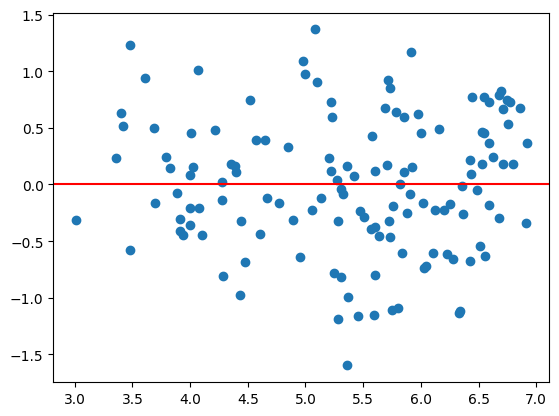

In [305]:
#Q4c
plt.scatter(model2.fittedvalues,model2.resid)
plt.axhline(0,color="red")


In [294]:
#Q5a
model3 = smf.ols("LifeSat ~ LE + EYS + logGNI + C(Region)", data=df_old).fit()
print(model3.summary())


                            OLS Regression Results                            
Dep. Variable:                LifeSat   R-squared:                       0.784
Model:                            OLS   Adj. R-squared:                  0.768
Method:                 Least Squares   F-statistic:                     49.89
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           4.84e-37
Time:                        16:41:30   Log-Likelihood:                -107.86
No. Observations:                 134   AIC:                             235.7
Df Residuals:                     124   BIC:                             264.7
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

In [ ]:
#Q5b

In [297]:
#Q5c
print(model3.params)
print()
print(model3.pvalues)

Intercept                                 -2.565616
C(Region)[T.Europe & Central Asia]        -0.143092
C(Region)[T.Latin America & Caribbean]     0.598290
C(Region)[T.Middle East & North Africa]   -0.122248
C(Region)[T.North America]                 0.601562
C(Region)[T.South Asia]                   -0.092136
C(Region)[T.Sub-Saharan Africa]           -0.010092
LE                                         0.027581
EYS                                        0.060913
logGNI                                     0.546778
dtype: float64

Intercept                                  7.980712e-03
C(Region)[T.Europe & Central Asia]         4.417262e-01
C(Region)[T.Latin America & Caribbean]     5.405770e-03
C(Region)[T.Middle East & North Africa]    5.848274e-01
C(Region)[T.North America]                 1.693918e-01
C(Region)[T.South Asia]                    7.431422e-01
C(Region)[T.Sub-Saharan Africa]            9.674619e-01
LE                                         8.846090e-02
EYS             

In [300]:
#Q5d
print(model2.rsquared)
print(model2.rsquared_adj)

print()
print(model3.rsquared)
print(model3.rsquared_adj)
#Model 3 performs better
#Adjusted R2 takes into account of the columns that do not contribute much in the output whereas normal R2 does not do that

0.7384176846774841
0.732381169708503

0.7835879663409447
0.7678806413173036


In [176]:
#Bonus
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error,root_mean_squared_error
from sklearn.model_selection import train_test_split

df_temp = df_temp[["LE","EYS","MYS","logGNI","LifeSat"]]
X = df_temp.drop("LifeSat",axis=1)
y = df_temp["LifeSat"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.27,random_state=42)

lr = LinearRegression()
lr.fit(X_train,y_train)

for col,coef in zip(X.columns,lr.coef_):
    print(f"The coef of the column {col} : {coef}")

y_pred = lr.predict(X_test)
r2 = r2_score(y_test,y_pred)

print()
print(f"The r2 score is : {r2_score(y_test,y_pred)}")
print(f"The mse score is : {mean_squared_error(y_test,y_pred)}")
print(f"The rmse score is : {root_mean_squared_error(y_test,y_pred)}")


The coef of the column LE : 0.04242143010343951
The coef of the column EYS : 0.02941838284257195
The coef of the column MYS : -0.0390641564392253
The coef of the column logGNI : 0.6271365370007225

The r2 score is : 0.6971549783569404
The mse score is : 0.41401252935394983
The rmse score is : 0.643438054014487
